# 🚀  Проект: вариант 2 (Багмет Марина Андреевна)

## Задание 1. A/B–тестирование
* **1.1 Условие**

Одной из основных задач аналитика в нашей команде является корректное проведение экспериментов. Для этого мы применяем метод A/B–тестирования. В ходе тестирования одной гипотезы целевой группе была предложена новая механика оплаты услуг на сайте, у контрольной группы оставалась базовая механика. В качестве задания вам необходимо проанализировать итоги эксперимента и сделать вывод, стоит ли запускать новую механику оплаты на всех пользователей.

* **1.2 Входные данные**

В качестве входных данных вы имеете 4 csv-файла:

* groups.csv – файл с информацией о принадлежности пользователя к контрольной или экспериментальной группе (А – контроль, B – целевая группа) 
* groups_add.csv – дополнительный файл с пользователями, который вам прислали спустя 2 дня после передачи данных
* active_studs.csv – файл с информацией о пользователях, которые зашли на платформу в дни проведения эксперимента. 
* checks.csv – файл с информацией об оплатах пользователей в дни проведения эксперимента. 

* **1.3 Вопросы**

Предлагаем вам ответить на следующие вопросы:

* На какие метрики вы смотрите в ходе анализа и почему?
* Имеются ли различия в показателях и с чем они могут быть связаны?
* Являются ли эти различия статистически значимыми?
* Стоит ли запускать новую механику на всех пользователей?
Данный список вопросов не является обязательным, и вы можете при своём ответе опираться на собственный план.

* **1.4 Требования к ответу**

При выполнении тестового задания необходимо использовать язык программирования Python. 
В файле обязательно должны быть комментарии к тем действиям, которые вы выполняете с данными. 
Файл должен представлять собой законченный отчёт с выводами, сделанными в ходе исследования.


### Импорт библиотек

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import ttest_ind

### Загрузка данных и знакомство с данными

In [2]:
groups = pd.read_csv('Проект_2_groups.csv', sep=';')
groups_add = pd.read_csv('Проект_2_group_add.csv')
active_studs = pd.read_csv('Проект_2_active_studs.csv')
checks = pd.read_csv('Проект_2_checks.csv', sep=';')

In [3]:
# Посмотрим внимательно на данные таблицы groups

groups.head()

,id,grp
0,1489,B
1,1627,A
2,1768,B
3,1783,B
4,1794,A


In [4]:
groups.tail()

,id,grp
74479,5692459,B
74480,5692572,B
74481,5692865,B
74482,5693667,B
74483,5694419,B


In [5]:
groups.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74484 entries, 0 to 74483
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      74484 non-null  int64 
 1   grp     74484 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


In [6]:
# Выше уже видно, что нет пропусков по данным, но посмотрим более явно:
groups.isna().sum()

id     0
grp    0
dtype: int64

In [7]:
# Проверим дубликаты
groups.duplicated().sum()

0

In [8]:
# Посмотрим на соотношение данных
groups['grp'].value_counts()

B    59813
A    14671
Name: grp, dtype: int64

**Вывод по таблице groups:** в таблице представлены данные о 74484 пользователях, данные не имеют пропусков и дубликатов, разбиты на 2 не равные группы.

In [9]:
# Посмотрим на данные таблицы groups_add
groups_add.head()

,id,grp
0,5694584,B
1,5694830,B
2,5695057,B
3,5698872,B
4,5699067,B


In [10]:
groups_add.tail()

,id,grp
87,200247820,B
88,201032527,B
89,201067612,B
90,201067653,B
91,201067659,B


In [11]:
groups_add.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      92 non-null     int64 
 1   grp     92 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.6+ KB


In [12]:
groups_add.isna().sum()

id     0
grp    0
dtype: int64

In [13]:
groups_add.duplicated().sum()

0

In [14]:
groups_add['grp'].value_counts()

B    70
A    22
Name: grp, dtype: int64

**Вывод по таблице groups_add**: в таблице представлены данные о 92 пользователях, данные не имеют пропусков и дубликатов, разбиты на 2 не равные группы. Данные о принадлежности пользователей к группам находятся в двух разных файлах, поэтому нужно их объединить в один датафрейм(сделаем это позже, после предварительной проверки двух оставшихся датафреймов).

In [15]:
# Посмотрим на данные active_studs

active_studs.head()

,student_id
0,581585
1,5723133
2,3276743
3,4238589
4,4475369


In [16]:
active_studs.tail()

,student_id
8336,1794344
8337,296883
8338,3598448
8339,3610547
8340,205705


In [17]:
active_studs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8341 entries, 0 to 8340
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   student_id  8341 non-null   int64
dtypes: int64(1)
memory usage: 65.3 KB


In [18]:
active_studs.isna().sum()

student_id    0
dtype: int64

In [19]:
active_studs.duplicated().sum()

0

In [20]:
round(active_studs.shape[0] / (groups.shape[0] + groups_add.shape[0]) * 100)

11

**Вывод по таблице active_studs**: всего 8341 пользователей, активных в период эксперимента(это 11% от всех зарегистрированных пользователей, распределенных по группам для эксперимента). Именно эти 11% и войдут в наш анализ, т.к новая механика оплаты услуг на сайте могла повлиять только на тех, кто был активен на сайте.

In [21]:
# Посмотрим на данные checks

checks.head()

,student_id,rev
0,1627,990.0
1,3185,690.0
2,25973,690.0
3,26280,690.0
4,100300,990.0


In [22]:
checks.tail()

,student_id,rev
536,5645737,1900.0
537,5651566,1900.0
538,5662322,1900.0
539,5681918,1900.0
540,5740903,1900.0


In [23]:
checks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  541 non-null    int64  
 1   rev         541 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 8.6 KB


In [24]:
checks.isna().sum()

student_id    0
rev           0
dtype: int64

In [25]:
checks.duplicated().sum()

0

In [26]:
checks.nunique()

student_id    541
rev            39
dtype: int64

In [27]:
checks.rev.describe()

count     541.000000
mean     1059.752317
std       762.712359
min       199.000000
25%       290.000000
50%       840.000000
75%      1900.000000
max      4650.000000
Name: rev, dtype: float64

* Количество данных: 541 чек об оплате.
* Минимальная стоимость покупки 199. Максимальная 4650.
* Средний чек составляет примерно 1059.Медианный чек, т.е типичная покупка, составляет 840. Это говорит об ассиметрии, т.к среднее значение сильно выше медианы. Т.е небольшое количество пользователей совершили дорогие покупки и за счет этого среднее значение выше.
*Стандартное отклонение составляет 762.71, что достаточно много при медиане в 840. Цены сильно разбросаны.
* Анализ квартилей:
    * 5% пользователей заплатили 290 или меньше.
    * 50% пользователей заплатили в диапазоне от 290 до 1900 (размах).
    * 25% самых "дорогих" клиентов заплатили от 1900 до 4650.


**Вывод по таблице checks**: данные чистые, но неоднородные, пропусков и полных дубликатов нет, всего зафиксирован 541 факт оплаты. Есть 39 уникальных ценовых предложений. При дальнейшем анализе нужно учесть асимметрию.

### Предподготовка данных и объединение таблиц

Необходимо объединить таблицы для дальнейшего анализа

In [28]:
# Соединяем groups и groups_add

all_groups = pd.concat([groups, groups_add], axis=0, ignore_index=True)
all_groups.head()

,id,grp
0,1489,B
1,1627,A
2,1768,B
3,1783,B
4,1794,A


In [29]:
# Проверим, совпадает ли количество пользователей

groups.shape[0] + groups_add.shape[0]

74576

In [30]:
all_groups.shape[0]

74576

In [31]:
# Приведём названия колонок к единому виду

all_groups_renamed = all_groups.rename(columns={'id': 'student_id'})

**Проверка на аномалии**

Прежде чем собрать один общий датасет со всеми данными, есть смысл проверить баги и аномалии. Возможно, есть пользователи, которые попали в оплату, но при этом они были не активны.

In [32]:
# Находим id всех активных студентов
active_ids = active_studs['student_id']

# Фильтруем таблицу checks 
anomalies = checks.query("student_id not in @active_ids")

print(f"Количество аномальных пользователей: {anomalies.shape[0]}")

Количество аномальных пользователей: 149


**Вывод:** найдено 149 аномальных пользователей. Это довольно весомое число, учитывая, что всего по данным 541 оплата (то есть почти 27% оплативших почему-то не зафиксировались как активные). Их исключение критически важно для точности A/B теста, так как эксперимент проверяет механику оплаты на сайте.

**Причины, по которым могла произойти такая ошибка:**

1) Ошибка авторизации(сессии). Пользователь мог зайти на сайт как неавторизованный «гость» (ему присвоился временный anonymous_id), дойти до корзины, оплатить, и только в момент создания личного кабинета система присвоила ему постоянный student_id. В итоге: в логах активности он остался под гостевым ID, а в таблице оплат уже под своим постоянным.

2) Сбой отправки ивентов (событий). В дни теста на сайте упал скрипт, отвечающий за отправку этих логов, событие активности не улетело на сервер. При этом лог оплаты создается на сервере банка и поэтому он зафиксирован.

3) Автоплатежи. возможно, у некоторых пользователей настроено автопродление, поэтому деньги списались автоматически по расписанию. При этом сами пользователи  могли вообще не заходить на сайт в этот период.

4) Блокировщики рекламы и скриптов. Возможно, у этих пользователей на браузере стояли различные плагины, которые иногда блокируют скрипты трекеров активности.

5) Человеческий фактор и ошибки дата-инженеров.


In [33]:
# Оставим в таблице оплат только тех студентов, которые были активны на сайте.

active_ids = active_studs['student_id']
checks = checks.query("student_id in @active_ids")

# Проверка оплат, очищенных от аномалий(было 541 оплата, из них 149 аномалий, должно остаться 392)

checks.shape[0]

392

In [34]:
# Объединим группы и активных пользователей

active_groups = pd.merge(all_groups_renamed, active_studs, on='student_id', how='inner')

# Подтянем данные об оплатах

df_full = pd.merge(active_groups, checks, on='student_id', how='left')

# Наведём порядок в названиях и пропусках

df_full = df_full.rename(columns={'grp': 'group', 'rev': 'revenue'})
df_full['revenue'] = df_full['revenue'].fillna(0)

# 4. Создадим флаг платящего пользователя(необходимо для дальнейшего анализа)

df_full['paying'] = (df_full['revenue'] > 0).astype(int)

In [35]:
df_full.head()

,student_id,group,revenue,paying
0,1627,A,990.0,1
1,2085,B,0.0,0
2,2215,B,0.0,0
3,3391,A,0.0,0
4,3401,B,0.0,0


In [36]:
# Посмотрим на распределение групп(количество пользователей в каждой группе)

group_counts = df_full['group'].value_counts()
print(group_counts)

# В процентах

group_percents = (df_full['group'].value_counts(normalize=True) * 100).round(2)
print(group_percents)

B    6803
A    1538
Name: group, dtype: int64
B    81.56
A    18.44
Name: group, dtype: float64


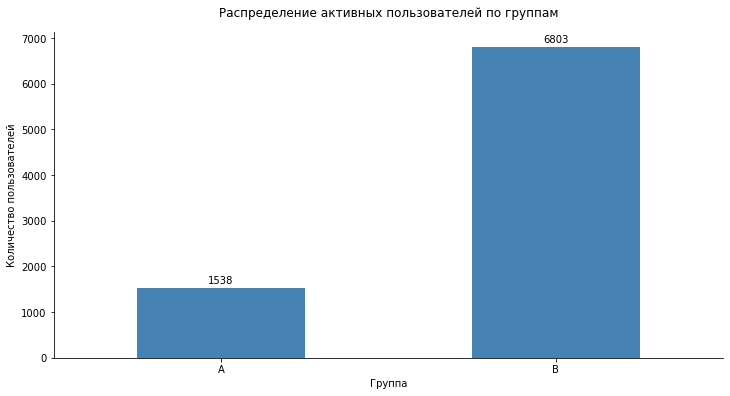

In [37]:
# Строим график 
ax = df_full['group'].value_counts().sort_index().plot(kind='bar', color='steelblue', rot=0, figsize=(12, 6))

#  Подписи значений
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 100, int(p.get_height()), ha='center')

# Название графика и подписи осей
plt.title('Распределение активных пользователей по группам', fontsize=12, pad=15)
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')

# Убираем рамки справа и сверху
sns.despine()

plt.show()

**Вывод**: сильный дисбаланс в размерах выборки. Тестовая группа B(‭6803 человек) почти в 4.5 раза превышает контрольную группу A(1538 человек).Но несмотря на дисбаланс, объемы обеих выборок достаточно велики(больше 1000).

### Выбор метрик 

Информация, на основе которой нужно определить метрики:
* Есть данные об активных пользователях и их оплатах, у группы А и В разные механики оплаты.

**Обоснование выбора метрик**

Для комплексной оценки новой механики оплаты используем систему взаимосвязанных метрик, которая покажет картину с разных сторон, это даст возможность оценить поведенческие и финансовые эффекты.

* **Конверсия в оплату (CR)**. Доля активных пользователей, совершивших хотя бы одну оплату. Позволит оценить, насколько новая механика удобна и привлекательна для пользователей (изменилось ли желание покупать). Если новая механика оплаты слишком сложная, непонятная или ломается, конверсия сразу упадет.

* **Средний чек платящего (ARPPU)** Средний доход на одного платящего пользователя. Покажет изменение покупательской способности и плотности монетизации (стали ли платить больше за один раз).

* **Средний доход с одного активного пользователя (ARPU)** — средняя выручка, приходящаяся на абсолютно каждого посетителя платформы за время теста. Выступает главным судьёй эксперимента, так как объединяет в себе сдвиги и в конверсии, и в среднем чеке (‭ARPU = CR * ARPPU‬‭‬‭‬), показывая финальную финансовую выгоду новой механики для бизнеса.

### метрикa  CR

**Расчет и проверка гипотез**

In [38]:
# Находим среднее по флагу оплаты (долю единиц) и переводим в проценты
cr_results = (df_full.groupby('group')['paying'].mean() * 100).round(2)

print("Конверсия в оплату (CR) по группам:")
print(cr_results)

Конверсия в оплату (CR) по группам:
group
A    5.07
B    4.62
Name: paying, dtype: float64


**Вывод**:в тестовой группе B (где внедрили новую механику оплаты) конверсия упала на 0.45 процентных пункта по сравнению с базовой версией.
Возможно, новая фича могла оказаться неудобной, непонятной или технически забагованной для пользователей,поэтому они стали реже доходить до покупки. Но делать окончательные выводы рано, пока мы не проверили статистику.

**Обоснование выбора критерия**

Метрика Conversion Rate является числовым показателем, но рассчитывается по категориальному признаку (paying), у которого в базе всего два исхода, т.е данные бинарные(‭1(купил) или 0(не купил)). Нормальности тут быть не может. Равенство дисперсий проверять не нужно. В данном случае следует использовать **критерий Хи-квадрат**, так как  он специально создан для работы с категориальными данными и долями.

**Сформулируем статистические гипотезы:**

* **Нулевая гипотеза (‭H_0)**: между новой механикой оплаты (группа B) и старой механикой (группа A) нет никакой разницы. Изменение конверсии с 5.07% до 4.62% абсолютно случайно и вызвано обычным шумом в данных.

* **Альтернативная гипотеза (‭H_1)**: между новой и старой механикой оплаты есть статистически значимая разница. Изменение конверсии не случайно, новая механика действительно повлияла на поведение пользователей (ухудшила его).

**Уровень значимости альфа** примем равным 0.05.

In [39]:
from scipy.stats import chi2_contingency

# Строим таблицу сопряженности (фактические исходы)
contingency_table = pd.crosstab(df_full['group'], df_full['paying'])
print("Таблица сопряженности:")
print(contingency_table)
print("-" * 30)

# Запускаем критерий Хи-квадрат
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"p-value: {p_value}")

a = 0.05  # порог значимости
if p_value < a:
    print('Отклоняем H_0')
else:
    print('Не отклоняем H_0')

Таблица сопряженности:
paying     0    1
group            
A       1460   78
B       6489  314
------------------------------
p-value: 0.48625240457231045
Не отклоняем H_0


**Результаты проверки гипотез для конверсии (CR):**

* Для сравнения конверсии между группами был применен критерий Хи-квадрат Пирсона.
* По результатам теста получен ‭p-value 0.486, что существенно выше классического уровня значимости ‭a=0.05‬‭‬.
* Статистический вывод: на текущих данных мы не имеем оснований отклонить нулевую гипотезу (‭H_0). Различия в конверсии между старой механиков оплаты (‭5.07) и новой (‭4.62) признаются статистически незначимыми и могут быть вызваны случайными колебаниями выборки.
* Бизнес-вывод: изменение механики оплаты никак не повлияло на готовность пользователей совершать покупки. Изменения случайны, конверсия в группах принципиально не отличается.

### Расчет метрик ARPPU и ARPU

Для метрик ARPPU и ARPU даны количественные данные(в денежном эквивалента). Здесь могут быть выбросы и разный разброс. Поэтому обязательно проверяем нормальность и дисперсию.

In [40]:
# Считаем ARPPU (среднее только по тем, у кого выручка больше нуля)
arppu_results = df_full[df_full['revenue'] > 0].groupby('group')['revenue'].mean().round(2)

# Считаем ARPU (среднее по пользователям в группе)
arpu_results = df_full.groupby('group')['revenue'].mean().round(2)

print("Средний доход на одного платящего пользователя (ARPPU):")
print(arppu_results)
print("-" * 30)
print("Средний доход на одного активного пользователя (ARPU):")
print(arpu_results)

Средний доход на одного платящего пользователя (ARPPU):
group
A     933.59
B    1257.88
Name: revenue, dtype: float64
------------------------------
Средний доход на одного активного пользователя (ARPU):
group
A    47.35
B    58.06
Name: revenue, dtype: float64


* ARPPU: вырос с 933.59 рублей в группе A до 1257.88 рублей в группе B (рост сразу на 34.7%).
* ARPU: вырос с 47.35 рублей в группе A до 58.06 рублей в группе B (рост примерно на 22.6%).

**Вывод**: те пользователи, которые решились на покупку в группе B, стали платить значительно больше. Средний чек покупателя вырос почти на треть. За счет этого вырос и общий средний доход на одного пользователя (ARPU).
На первый взгляд новая механика выглядит успешной и прибыльной, но докажем это статистически.

**Визуальный анализ распределений**

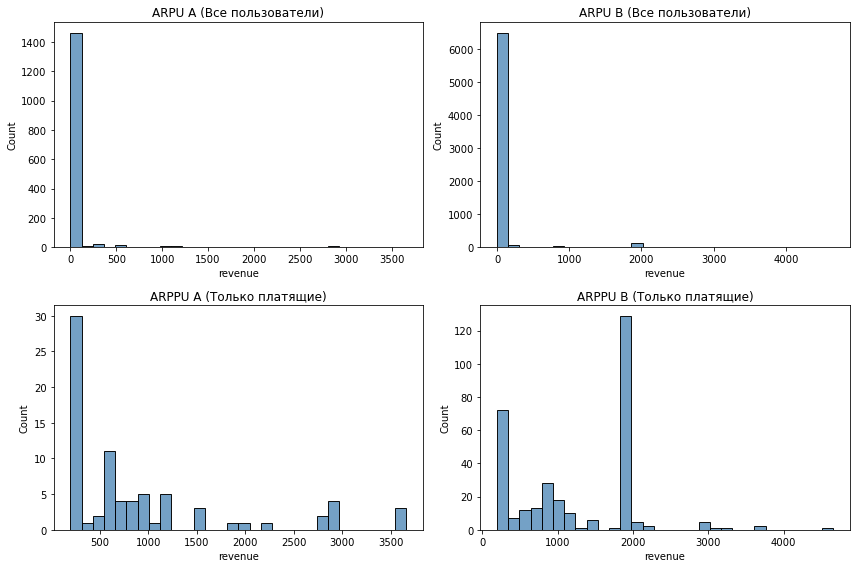

In [41]:
# Создаем сетку 2 на 2 для графиков
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Верхний ряд: ARPU (Все пользователи, включая нули)
sns.histplot(data=df_full.query("group == 'A'"), x='revenue', bins=30, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('ARPU A (Все пользователи)')

sns.histplot(data=df_full.query("group == 'B'"), x='revenue', bins=30, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('ARPU B (Все пользователи)')

# Нижний ряд: ARPPU (Только платящие пользователи)
sns.histplot(data=df_full.query("group == 'A' and revenue > 0"), x='revenue', bins=30, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('ARPPU A (Только платящие)')

sns.histplot(data=df_full.query("group == 'B' and revenue > 0"), x='revenue', bins=30, ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('ARPPU B (Только платящие)')

plt.tight_layout()
plt.show()

**Метрика ARPU (Верхний ряд графиков):**
Распределения полной выручки в обеих группах демонстрируют экстремальную правостороннюю асимметрию. Мы наблюдаем колоссальный пик (спайк) в районе нуля. Распределение является ненормальным. Более подробно проанализируем эту ситуцию, когда дойдём до стат.критерия ARPU.

**Метрика ARPPU (Нижний ряд графиков):**
Наблюдается ярко выраженная ступенчатая структура. Это указывает на то, что в продукте существует фиксированная тарифная сетка, и пользователи массово выбирают определенные пакетные предложения.

### Метрика ARPPU, проверка гипотез

**Проверка на нормальность и тест Шапиро-Уилка**

ARPPU рассчитывается исключительно по платящим пользователям и здесь Шапиро-Уилка выигрывает у всех остальных критериев по одной главной причине: размер выборки. Исходя из расчетов видно, что в группе А 78 платящих пользователей, в группе В 314. Это маленькая выборка.

In [42]:
# Считаем, сколько человек платили (revenue > 0) и не платили (revenue == 0) в каждой группе
print(pd.crosstab(df_full['group'], df_full['revenue'] > 0))

revenue  False  True 
group                
A         1460     78
B         6489    314


**Сформулируем статистические гипотезы:**
* **Нулевая гипотеза (H_0):** Распределение выручки платящих пользователей в группе является **нормальным**.
* **Альтернативная гипотеза (H_1):** Распределение выручки платящих пользователей в группе **существенно отличается от нормального**.

**Уровень значимости альфа** примем равным 0.05.

In [43]:
# Фильтруем данные 
pay_A = df_full.query("group == 'A' and revenue > 0")['revenue']
pay_B = df_full.query("group == 'B' and revenue > 0")['revenue']

# Запускаем тест Шапиро-Уилка
stat_A, p_val_A = shapiro(pay_A)
stat_B, p_val_B = shapiro(pay_B)

print(f"Группа A p-value: {p_val_A}")
print(f"Группа B p-value: {p_val_B}")

Группа A p-value: 1.49869203824321e-10
Группа B p-value: 1.5433362141142128e-16


In [44]:
print(f"Группа A p-value: {p_val_A:.12f}")
print(f"Группа B p-value: {p_val_B:.18f}")

Группа A p-value: 0.000000000150
Группа B p-value: 0.000000000000000154


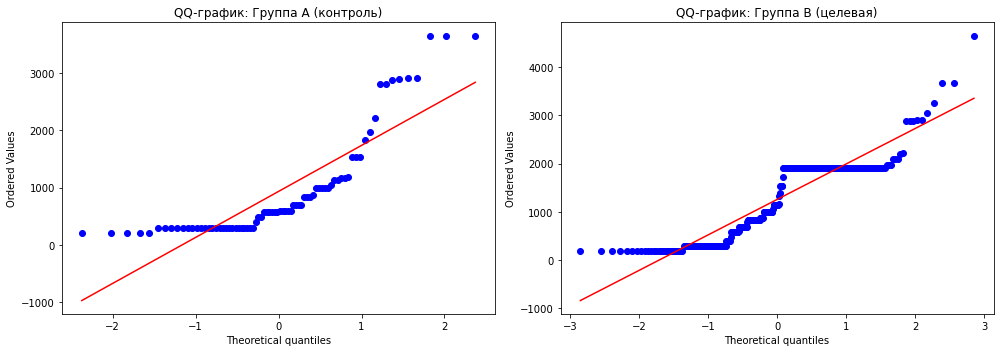

In [45]:
# Создаем сетку из 2 графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Строим QQ-плоты для платящих пользователей 
stats.probplot(pay_A, dist="norm", plot=axes[0])
axes[0].set_title('QQ-график: Группа А (контроль)')

stats.probplot(pay_B, dist="norm", plot=axes[1])
axes[1].set_title('QQ-график: Группа B (целевая)')

plt.tight_layout()
plt.show()

**Вывод**: для обеих групп полученное значение p-value критически меньше принятого уровня значимости a=0.05, поэтому отклоняем нулевую гипотезу (H_0). Распределение ARPPU как в контрольной, так и в тестовой группах не является нормальным.

QQ-графики наглядно подтверждают результаты теста Шапиро-Уилка о ненормальности распределения выручки среди платящих пользователей в обеих группах(есть ступенчатость и отклонения в хвостах).

**Проверка дисперсий и критерий Левена**

Теперь нам нужно понять масштаб разброса, т.е насколько сильно и одинаково ли отклоняются чеки вокруг среднего значения в обеих группах. Для этого проверим дисперсии. Здесь нам поможет критерий Левена, т.к данные распределены не нормально.

**Сформулируем статистические гипотезы:**

* **Нулевая гипотеза (‭H_0‬)**: дисперсии (разброс выручки) в группах А и B равны (гомогенность дисперсий соблюдена).
* **Альтернативная гипотеза (‭H_1‬)**: дисперсии в группах А и B существенно различаются (гетероскедастичность данных).

**Уровень значимости альфа** примем равным 0.05.

In [46]:
# Запускаем критерий Левена
stat_levene, p_val_levene = levene(pay_A, pay_B)

print("Результаты критерия Левена:")
print(f"p-value: {p_val_levene}")

Результаты критерия Левена:
p-value: 0.08025675761347022


**Вывод:** полученное значение p-value 0.08 превышает выбранный уровень значимости a=0.05, а значит **не отклоняем нулевую гипотезу (H_0)**. Дисперсии платящих пользователей в группах А и B можно считать **гомогенными (равными)**. Масштаб разброса сумм покупок в контрольной и тестовой группах принципиально не отличается.

**Запускаем финальный стат.тест для сравнения чеков ARPPU**

Результаты теста Левена позволяют применить Т-тест Стьюдента. Несмотря на то, что данные распределены не нормально, размер выборок(А=78, В=314) обеспечивает достаточную точность.

**Сформулируем статистические гипотезы:**

* **Нулевая гипотеза (‭H_0)**: Средние чеки (ARPPU) в группах А и B равны (разница между 933 руб. и 1257 руб. вызвана случайностью).
* **Альтернативная гипотеза (‭H_1‬)**: Средние чеки в группах А и B значимо различаются (механика оплаты реально повлияла на сумму покупок).

**Уровень значимости альфа** примем равным 0.05.

In [47]:
# Запускаем Т-тест Стьюдента (так как дисперсии равны, ставим equal_var=True)
stat_t, p_val_t = ttest_ind(pay_A, pay_B, equal_var=True)

print("Результаты Т-теста для ARPPU:")
print(f"p-value: {p_val_t}")

Результаты Т-теста для ARPPU:
p-value: 0.001856202526576587


**Вывод**: полученный ‭p-value(0.0019) значительно меньше, чем стандартный уровень значимости ‭a= 0.05, поэтому **отклоняем нулевую гипотезу (‭H_0)** в пользу альтернативной (‭H_1‬).

Изменение механики оплаты привело к статистически значимому росту среднего чека платящих пользователей (ARPPU) в тестовой группе B по сравнению с контрольной группой А. Этот рост не является случайным колебанием данных.

###  Метрика ARPU, проверка гипотез

Метрика ARPU рассчитывается по всей совокупности активных пользователей, включая тех, кто не совершил ни одной покупки (`revenue = 0`). 



In [48]:
# Показываем процент пользователей с нулевой выручкой в каждой группе
zero_rev_count = df_full[df_full['revenue'] == 0].groupby('group')['student_id'].count()
total_count = df_full.groupby('group')['student_id'].count()

zero_revenue_share = (zero_rev_count / total_count * 100).round(2)

print("Процент неплатящих пользователей (нулей в revenue):")
print(zero_revenue_share)

Процент неплатящих пользователей (нулей в revenue):
group
A    94.93
B    95.38
Name: student_id, dtype: float64


Так как неплатящие пользователи составляют порядка 95% всей выборки, распределение имеет огромный пик (спайк) в нуле и является экстремально асимметричным(выяснили ранее).

Использовать формальные критерии нормальности (такие как тест Д'Агостино-Пирсона или Шапиро-Уилка) для ARPU методологически некорректно. Распределение гарантированно не является нормальным.

Несмотря на то, что распределение ARPU не является нормальным, размеры наших выборок большие (‭A=1538, ‭B=6803‭‬). Согласно Центральной Предельной Теореме, при таких больших объемах данных распределение выборочных средних стремится к нормальному. Это позволяет нам абсолютно законно использовать t-тест Уэлча для сравнения ARPU, так как он устойчив к отклонениям от нормальности на больших данных. Здесь бы ещё подошёл Bootstrap(бутстрап), он работает на любых данных, но он достаточно тяжелый, ему нужно много мощностей.

**Сформулируем статистические гипотезы:**

* **Нулевая гипотеза (H_0):** Средний доход на одного активного пользователя (ARPU) в группах А и B **равен** (различия между 47.35 руб. и 58.06 руб. случайны).
* **Альтернативная гипотеза (H_1):** Средний доход на одного активного пользователя (ARPU) в группах А и B **значимо различается** (новая механика оплаты повлияла на общую выручку со всех зашедших пользователей).

**Уровень значимости** принимаем равным 0.05.

In [49]:
# Выручка всех пользователей по группам (вместе с нулями)
arpu_A = df_full.query("group == 'A'")['revenue']
arpu_B = df_full.query("group == 'B'")['revenue']

# Запускаем Т-тест Уэлча (за это отвечает параметр equal_var=False)
stat_arpu, p_val_arpu = ttest_ind(arpu_A, arpu_B, equal_var=False)

print("Результаты Т-теста Уэлча для ARPU:")
print(f"p-value: {p_val_arpu}")

Результаты Т-теста Уэлча для ARPU:
p-value: 0.19843583641451018


**Вывод**: полученное значение p-value 0.198 превышает выбранный уровень значимости a=0.05, поэтому **не отклоняем нулевую гипотезу (H_0)**.

Несмотря на то, что средний чек платящих пользователей (ARPPU) в группе B статистически значимо вырос, **общий средний доход на одного активного пользователя (ARPU) между группами А и B не имеет статистически значимых различий**. Наблюдаемое изменение ARPU с 47.35 руб. до 58.06 руб. с высокой вероятностью является результатом случайного колебания данных.

### Общий вывод и бизнес-рекомендации по результатам A/B тестирования

В ходе исследования была проведена оценка новой механики оплаты на платформе. Целевой задачей эксперимента являлось определить, привело ли нововведение к росту эффективности бизнеса.

Для анализа мы скомбинировали три ключевые продуктовые метрики: **Конверсию в покупку (CR)**, **Средний доход на платящего пользователя (ARPPU)** и **Средний доход на одного активного пользователя (ARPU)**.

Подробная интерпретация метрик:

* **Конверсия в покупку (CR):** несмотря на то, что в тестовой группе процент покупателей снизился с 5.07% до 4.62%, критерий Хи-квадрат показал, что это отклонение лежит в пределах случайных колебаний данных. Изменение механики оплаты значимо не ухудшило и не улучшило желание пользователей покупать.

* **Доход на платящего (ARPPU):** здесь мы зафиксировали подтвержденный статистикой эффект. Те пользователи, которые всё-таки совершили покупку в новой системе, стали тратить в среднем на 35% больше (рост с 933 до 1257 рублей). Т-тест Стьюдента (обоснованный равенством дисперсий по тесту Левена) подтверждает, что этот рост не случаен.

* **Доход на активного пользователя(ARPU):** Это главная метрика успешности эксперимента, объединяющая в себе и конверсию, и чеки. Т-тест Уэлча (выбранный из-за сильной асимметрии данных и обилия нулей) показал результат p-value 0.20. Это означает, что наблюдаемый рост общего дохода с 47.35 до 58.06 рублей не является статистически значимым.

Получился некий парадокс!) Но его можно объяснить примерно так: произошло перераспределение денег внутри выборки, новая механика не дала прироста в конверсии, но при этом подтолкнула платящую аудиторию совершать более дорогие и крупные покупки. По итогу произошёл некий баланс: с одной стороны, увеличился заработок с одного платящего, но из-за отсутствия роста базы покупателей, выручка с активного пользователя не увеличилась.

**Финальная рекомендация для бизнеса**

**Не рекомендовано раскатывать новую механику оплаты на всех пользователей в текущем виде.** Продуктовой команде рекомендуется отправить обновление на доработку: нужно изучить воронку тест-группы B и выяснить, почему не платят остальные 95% пользователей. Задача: сохранить высокий чек и поднять конверсию.

## Задание 2. SQL
Сегментация клиентов для персонализированного маркетинга

**2.1 Бизнес-контекст**

CRM-отдел строит систему сегментации клиентов для триггерных рассылок на основе истории покупок. Сегмент клиента определяет тип маркетинговой коммуникации.

Особенность данных: текущая дата для расчётов — 31 марта 2024 года.

**2.2 Описание таблиц и полей, которые могут пригодиться для решения задания**

Все таблицы можно найти в Redash в схеме StartDA (lab) – это те же таблицы, с которыми вы работали в блоке SQL.

* **customers** — информация о клиентах
* **orders** — информация о заказах
* **customer_actions** — информация о действиях пользователей

**2.3 Задача**

Проведите сегментацию клиентов по состоянию на 31 марта 2024. Требуемые поля в выводе для каждого клиента: customer_id, customer_city, registration_date (дата регистрации), days_since_registration (число дней с даты регистрации), orders_count (число доставленных заказов), purchase_events_count (число событий покупки — Purchase), avg_delivery_days (среднее время доставки в днях), segment (сегмент).

Задание можно запушить в виде txt-файла, содержащего в себе текст запроса – как вариант, можно вставить его в Jupyter-файл в виде многострочной строки или в другом формате, позволяющем легко прочитать текст запроса и скопировать его.

**2.4 Напутствия**

EXTRACT(EPOCH FROM (order_delivered_customer_time - order_created_time)) / 86400.0 – это выражение преобразует разницу между датой доставки и датой создания заказа из интервала времени в дни с десятичной дробью для точного расчёта среднего времени доставки.
Принцип работы CASE: Условия проверяются сверху вниз. Как только нашлось первое совпадение — остальные игнорируются.

In [50]:
"""
-- 1. Считаем метрики доставленных заказов и среднего времени доставки
WITH delivered_orders AS (
    SELECT 
        customer_id,
        COUNT(order_id) AS orders_count,
        AVG(EXTRACT(EPOCH FROM (order_delivered_customer_time - order_created_time)) / 86400.0) AS avg_delivery_days
    FROM orders
    WHERE order_status = 'Delivered'
    GROUP BY customer_id
), 
-- 2. Считаем количество событий покупки
purchase_events AS ( 
    SELECT 
        customer_id,
        COUNT(*) AS purchase_events_count
    FROM customer_actions
    WHERE event_type = 'Purchase'
    GROUP BY customer_id
)
-- 3. Собираем итоговую витрину
SELECT 
    c.customer_id,
    c.customer_city,
    DATE(c.created_at) AS registration_date,
    DATE('2024-03-31') - DATE(c.created_at) AS days_since_registration,
    COALESCE(d.orders_count, 0) AS orders_count,
    COALESCE(p.purchase_events_count, 0) AS purchase_events_count,
    ROUND(d.avg_delivery_days::NUMERIC, 2) AS avg_delivery_days,
    CASE -- 4. Задаём логику сегментации методом исключения
        WHEN COALESCE(d.orders_count, 0) >= 3 THEN 'Постоянный'
        WHEN COALESCE(d.orders_count, 0) IN (1, 2) THEN 'Разовый'
        WHEN COALESCE(d.orders_count, 0) = 0
             AND DATE('2024-03-31') - DATE(c.created_at) > 30 THEN 'Неактивный'
        ELSE 'Новый'
    END AS segment
FROM customers c
LEFT JOIN delivered_orders d ON c.customer_id = d.customer_id
LEFT JOIN purchase_events p ON c.customer_id = p.customer_id

"""

"\n-- 1. Считаем метрики доставленных заказов и среднего времени доставки\nWITH delivered_orders AS (\n    SELECT \n        customer_id,\n        COUNT(order_id) AS orders_count,\n        AVG(EXTRACT(EPOCH FROM (order_delivered_customer_time - order_created_time)) / 86400.0) AS avg_delivery_days\n    FROM orders\n    WHERE order_status = 'Delivered'\n    GROUP BY customer_id\n), \n-- 2. Считаем количество событий покупки\npurchase_events AS ( \n    SELECT \n        customer_id,\n        COUNT(*) AS purchase_events_count\n    FROM customer_actions\n    WHERE event_type = 'Purchase'\n    GROUP BY customer_id\n)\n-- 3. Собираем итоговую витрину\nSELECT \n    c.customer_id,\n    c.customer_city,\n    DATE(c.created_at) AS registration_date,\n    DATE('2024-03-31') - DATE(c.created_at) AS days_since_registration,\n    COALESCE(d.orders_count, 0) AS orders_count,\n    COALESCE(p.purchase_events_count, 0) AS purchase_events_count,\n    ROUND(d.avg_delivery_days::NUMERIC, 2) AS avg_delivery_da

**Описание решения и его этапы**

* Расчет количества доставленных заказов для каждого клиента и среднего времени доставки заказов
* Расчет количества оплаченных покупок
* Основной запрос: при помощи конструкици CASE прописали логику для сегментации клиентов.
    * "Постоянный" - 3 и более доставленных заказов
    * "Разовый" - 1 или 2 доставленных заказов
    * "Неактивный" - 0 заказов(регистрация была более 30 дней назад)
    * "Новый" - 0 заказов(регистрация до 30 дней назад(включая 30))

## Задание 3. Python
Задача

* Реализуйте функцию, которая будет автоматически подгружать информацию из дополнительного файла groups_add.csv (заголовки могут отличаться) и на основании дополнительных параметров пересчитывать метрики.

* Реализуйте функцию, которая будет строить графики по получаемым метрикам.

Так как данные изначально лежат по ссылке на яндекс диске, и чисто по логике обновленные данные мы получим именно оттуда, я решила попробовать реализовать эту функцию через подгрузку данных с диска.

Загрузка данных с Яндекс.Диска...
Данные успешно загружены! Начинаем обработку...

Итоговая таблица метрик:
----------------------------------------------------------------------
       users  paying_users  total_revenue    CR   ARPU    ARPPU
group                                                          
A       1538            78     72820.0000  5.07  47.35   933.59
B       6803           314    394974.0035  4.62  58.06  1257.88
----------------------------------------------------------------------


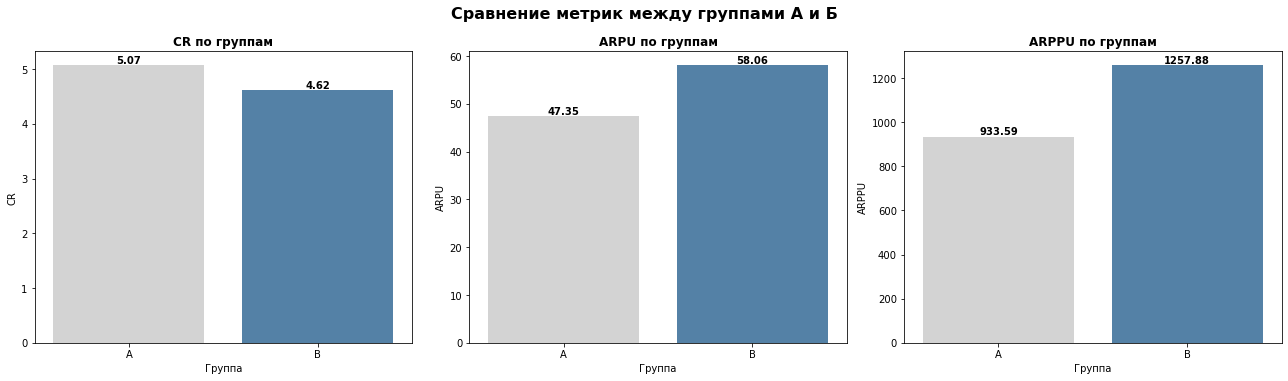

In [51]:
import io
import pandas as pd
import requests
from urllib.parse import urlencode
import matplotlib.pyplot as plt
import seaborn as sns

def download_yandex_disk_csv(public_link):
    """
    Вспомогательная функция для скачивания CSV-файлов напрямую с Яндекс.Диска.
    Автоматически определяет разделители.
    """
    base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
    final_url = base_url + urlencode(dict(public_key=public_link))
    
    response = requests.get(final_url)
    if response.status_code == 200:
        download_url = response.json()['href']
        file_response = requests.get(download_url)
        # Считываем текстовый поток, sep=None включает автоопределение разделителя (, или ;)
        return pd.read_csv(io.StringIO(file_response.text), sep=None, engine='python')
    else:
        raise Exception(f"Не удалось скачать файл по ссылке: {public_link}")

def calculate_ab_metrics(groups_link, groups_add_link, active_studs_link, checks_link):
    """
    Основная функция: скачивает все 4 файла, стандартизирует колонки,
    объединяет данные и рассчитывает метрики (CR, ARPU, ARPPU) для активных пользователей.
    """
    print("Загрузка данных с Яндекс.Диска...")
    df_groups = download_yandex_disk_csv(groups_link)
    df_groups_add = download_yandex_disk_csv(groups_add_link)
    df_active_studs = download_yandex_disk_csv(active_studs_link)
    df_checks = download_yandex_disk_csv(checks_link)
    print("Данные успешно загружены! Начинаем обработку...")
    
    # Приводим к нижнему регистру
    df_groups_add.columns = [col.lower() for col in df_groups_add.columns]
    
    # Поиск нужных колонок по ключевым словам id и grp/group
    id_col = [col for col in df_groups_add.columns if 'id' in col]
    grp_col = [col for col in df_groups_add.columns if 'grp' in col or 'group' in col]
    
    # Проверка: если хотя бы один список пустой, вызываем ошибку
    if not id_col or not grp_col: 
        raise ValueError("В дополнительном файле не таких колонок!")
        
    # Переименуем в единый стандарт
    df_groups_add = df_groups_add.rename(columns={id_col[0]: 'student_id', grp_col[0]: 'group'})
    
    # Стандартизация остальных датафреймов 'student_id' и 'revenue'
    df_groups_clean = df_groups.rename(columns={'id': 'student_id', 'grp': 'group'}, errors='ignore')
    df_active_clean = df_active_studs.rename(columns={'id': 'student_id'}, errors='ignore')
    df_checks_clean = df_checks.rename(columns={'id': 'student_id', 'rev': 'revenue'}, errors='ignore')
    
    # Объединение списков пользователей (основного и дополнительного)
    group_all = pd.concat([df_groups_clean, df_groups_add], ignore_index=True)
    group_all = group_all.drop_duplicates(subset=['student_id'])
    
    # Формирование когорты активных пользователей(другой метод, через left join, к активным прикрепляем данные)
    active_group = df_active_clean.merge(group_all, on='student_id', how='left')
    active_group = active_group.merge(df_checks_clean, on='student_id', how='left')
    
    # Заменяем отсутствующие чеки NaN нулями
    active_group['revenue'] = active_group['revenue'].fillna(0)
    
    # Агрегация данных по группам 
    final_result = active_group.groupby('group').agg(
        users=('student_id', 'nunique'),
        paying_users=('revenue', lambda x: (x > 0).sum()),
        revenue_user=('revenue', 'sum'))
    
    # Переименовываем агрегированную колонку выручки в понятный 'total_revenue'
    final_result = final_result.rename(columns={'revenue_user': 'total_revenue'})
    
    # Расчет метрик
    final_result['CR'] = ((final_result['paying_users'] / final_result['users']) * 100).round(2)
    final_result['ARPU'] = (final_result['total_revenue'] / final_result['users']).round(2)
    final_result['ARPPU'] = (final_result['total_revenue'] / final_result['paying_users']).round(2)
    
    return final_result

def vizualization_final_results(check):
    """Построение графиков метрик"""
    metrics_name = ['CR', 'ARPU', 'ARPPU']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Сравнение метрик между группами А и Б', fontsize=16, fontweight='bold', y=1.05)
    
    df_plot = check.reset_index()
    
    # Создаем свою палитру: серый и синий
    my_colors = ['lightgrey', 'steelblue'] 
    
    for i, metric in enumerate(metrics_name):
        ax = axes[i]
        sns.barplot(data=df_plot, x='group', y=metric, ax=ax, palette=my_colors)
        
        ax.set_title(f'{metric} по группам', fontsize=12, fontweight='semibold')
        ax.set_xlabel('Группа')
        ax.set_ylabel(metric)
        # Отрисовка точных значений над столбцами
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f"{height:.2f}", 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext=(0, 5), 
                        textcoords='offset points', 
                        fontsize=10, fontweight='bold')
            
    plt.tight_layout()
    plt.show()

# --------------------------------------------------------
# Запускаем анализ
# -------------------------------------------------------

# Прописываем все ссылки на файлы с Яндекс.Диска
link_groups = "https://disk.yandex.ru/d/UhyYx41rTt3clQ"
link_groups_add = "https://disk.yandex.ru/d/5Kxrz02m3IBUwQ"
link_active_studs = "https://disk.yandex.ru/d/Tbs44Bm6H_FwFQ"
link_checks = "https://disk.yandex.ru/d/pH1q-VqcxXjsVA"

# Запускаем расчет
metrics_df = calculate_ab_metrics(
    groups_link=link_groups,
    groups_add_link=link_groups_add,
    active_studs_link=link_active_studs,
    checks_link=link_checks)

# Выводим результат
print("\nИтоговая таблица метрик:")
print("-" * 70)
print(metrics_df)
print("-" * 70)

# Строим визуализацию
vizualization_final_results(metrics_df)